In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=sns.load_dataset("iris")

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
print("Shape",df.shape)

Shape (150, 5)


In [5]:
print("columns:",df.columns)

columns: Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


In [6]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [8]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

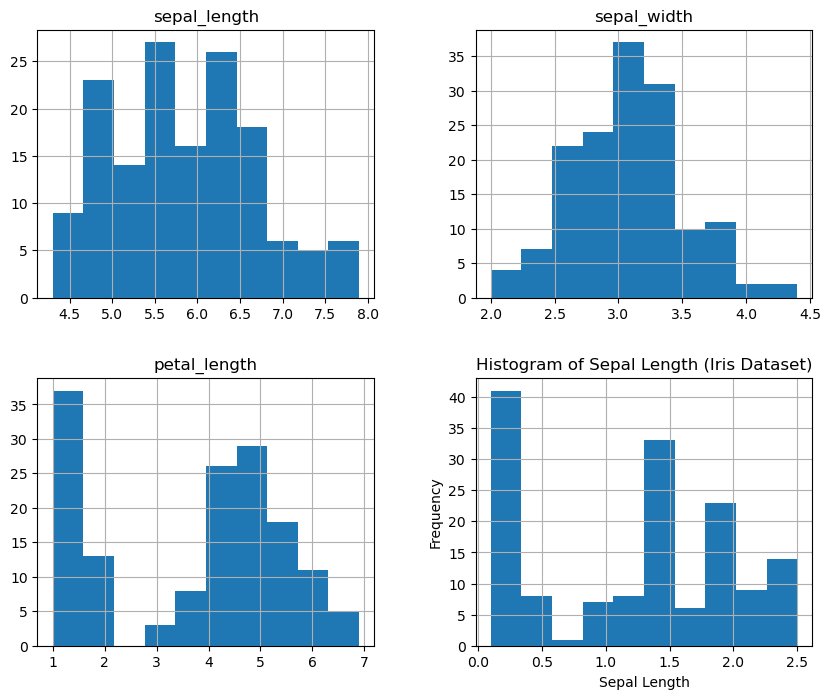

In [9]:
df.hist(figsize=(10,8))
plt.title("Histogram of Sepal Length (Iris Dataset)")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()

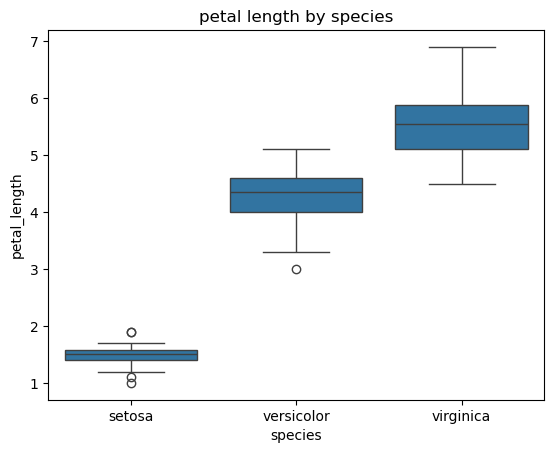

In [10]:
plt.figure()
sns.boxplot(x="species",y="petal_length",data=df)
plt.title("petal length by species")
plt.show()

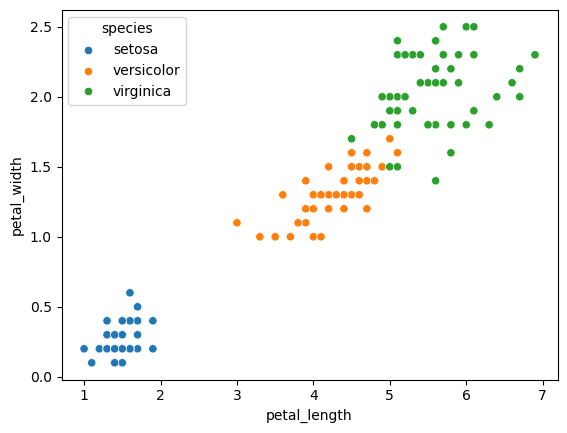

In [11]:
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species")
plt.show()

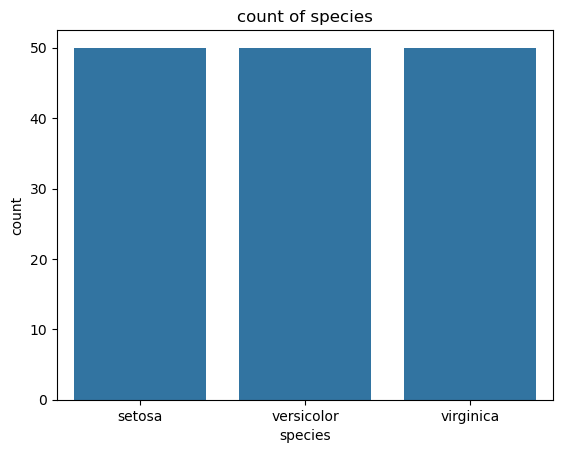

In [12]:
plt.figure()
sns.countplot(x=df['species'])
plt.title("count of species")
plt.show()

In [13]:
print(df.corr(numeric_only=True))

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


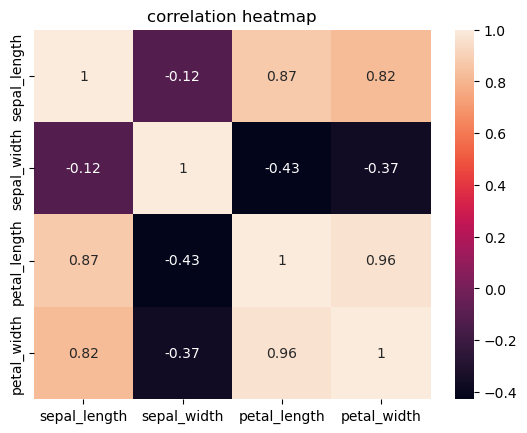

In [14]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("correlation heatmap")
plt.show()

In [15]:
print(df.groupby("species").mean())

            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026


In [16]:
print("Max Values")
print(df.max(numeric_only=True))



Max Values
sepal_length    7.9
sepal_width     4.4
petal_length    6.9
petal_width     2.5
dtype: float64


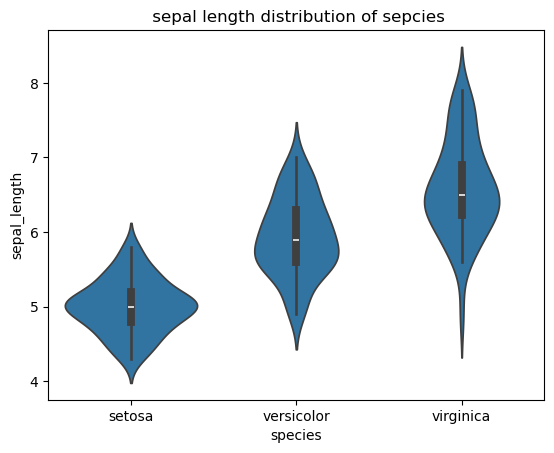

In [17]:
plt.figure()
sns.violinplot(x="species",y="sepal_length",data=df)
plt.title(" sepal length distribution of sepcies")
plt.show()

In [18]:
print("Min Values")
print(df.min(numeric_only=True))

Min Values
sepal_length    4.3
sepal_width     2.0
petal_length    1.0
petal_width     0.1
dtype: float64


IQR method

In [19]:
Q1=df['sepal_width'].quantile(0.25)
Q2=df['sepal_width'].quantile(0.50)
Q3=df['sepal_width'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

outliers=df[(df['sepal_width']<lower_bound) | (df['sepal_width']>lower_bound)]
print(f"Number of outliers : {len(outliers)}")
print(outliers[['sepal_width']].head())

Number of outliers : 150
   sepal_width
0          3.5
1          3.0
2          3.2
3          3.1
4          3.6


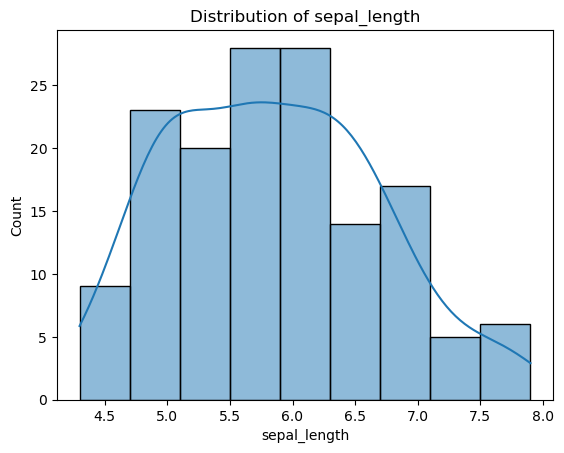

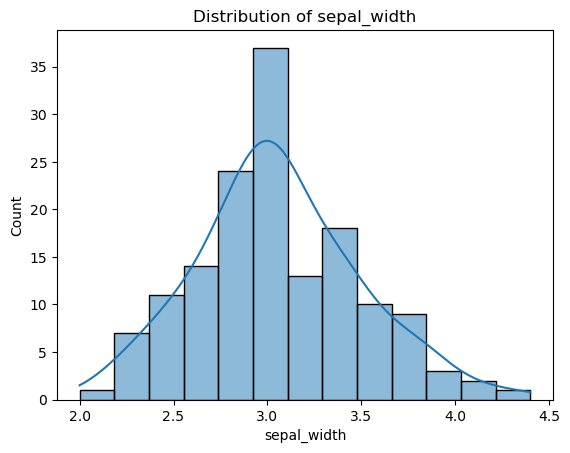

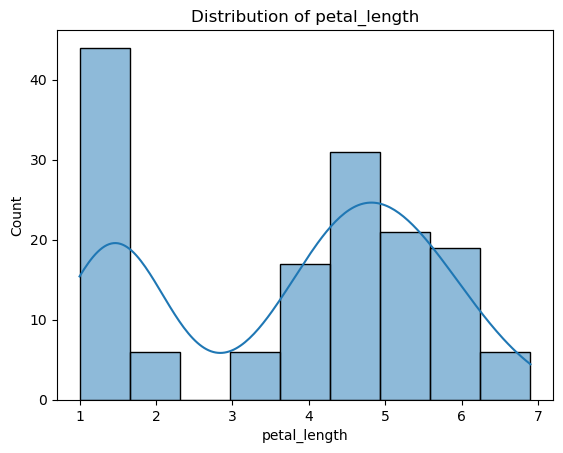

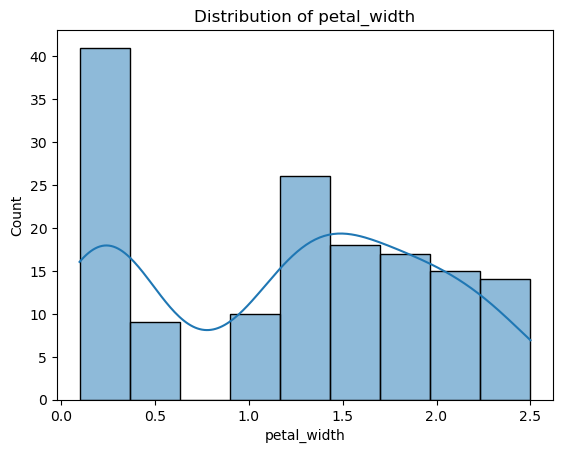

In [20]:
df.skew(numeric_only=True)

for col in df.columns[:-1]:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

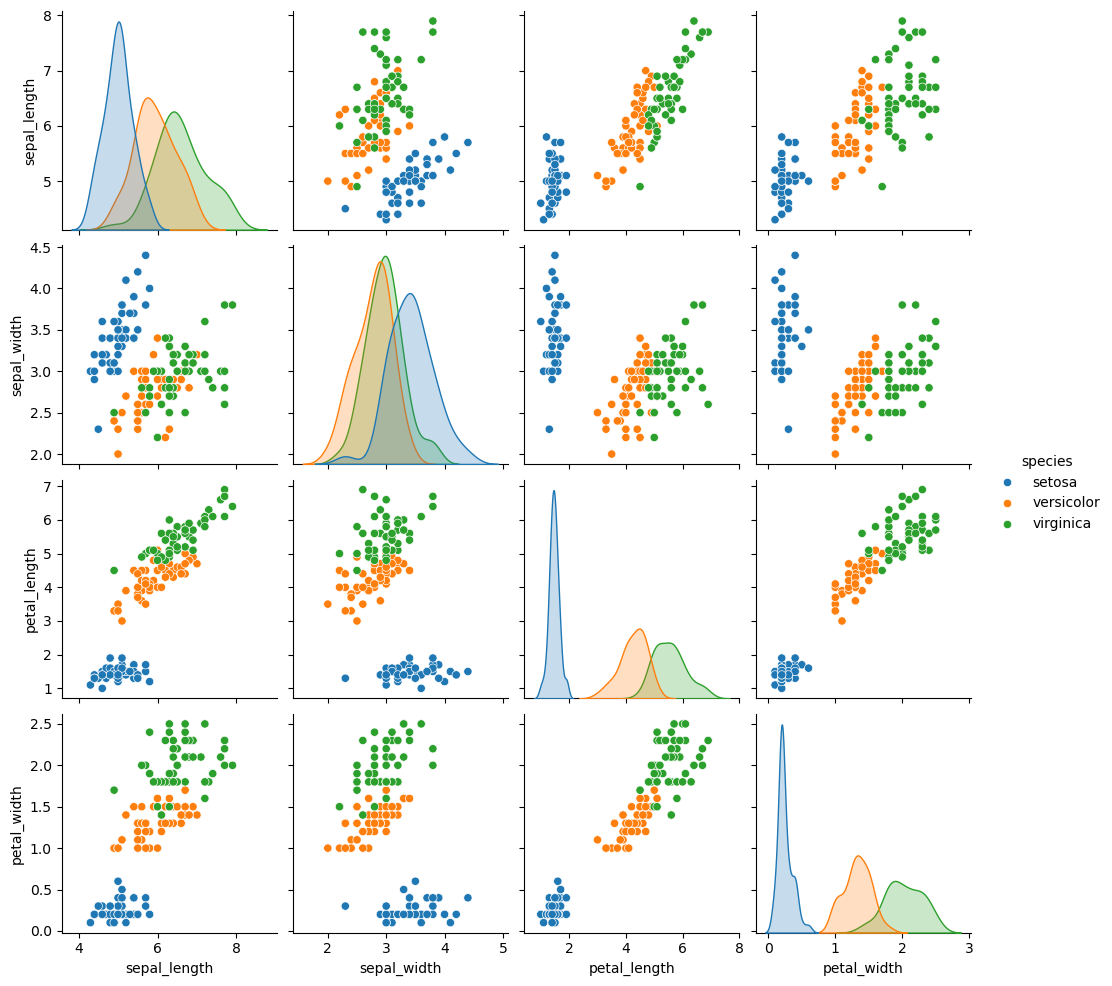

In [21]:
sns.pairplot(df, hue='species')
plt.show()